In [1]:
import cv2
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
print(cv2.__version__)

4.12.0


In [4]:
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

In [2]:
img = cv2.imread('img/sample.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [5]:
# Reading in the image and creating copies
img = cv2.imread('img/train5.jpg')
img = cv2.resize(img, (240, 240), interpolation=cv2.INTER_CUBIC)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # convert BGR (cv2) to RGB

In [6]:
# Input for Challenge 1
# Reading in the image and creating copies
img = cv2.imread('img/bike.jpg')
#img = cv2.resize(img, (240, 240), interpolation=cv2.INTER_CUBIC)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # convert BGR (cv2) to RGB

In [5]:
# Input for Challenge 2
# Reading in the image and creating copies
img = cv2.imread('img/skyline.jpg')
#img = cv2.resize(img, (240, 240), interpolation=cv2.INTER_CUBIC)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # convert BGR (cv2) to RGB

NameError: name 'cv2' is not defined

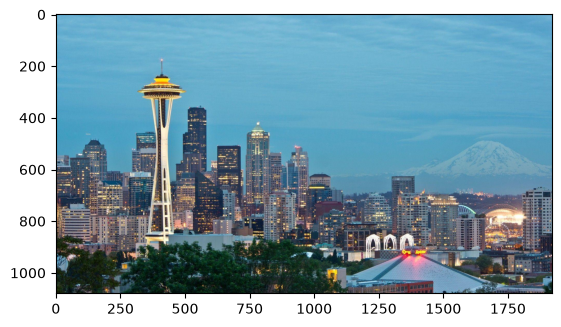

In [8]:
plt.imshow(img)

In [8]:
img_copy1 = img.copy()
img_copy2 = img.copy()
img_copy3 = img.copy()

In [10]:
#function to detect a face
def detect_face(img):
    face_img = img.copy()
    face_rect = face_cascade.detectMultiScale(face_img, scaleFactor = 1.1, minNeighbors = 5)

    for(x, y, w, h) in face_rect:
        # green box for face
        cv2.rectangle(face_img, (x,y), (x + w, y + h), (0,255,0), 1)

    return face_img

True

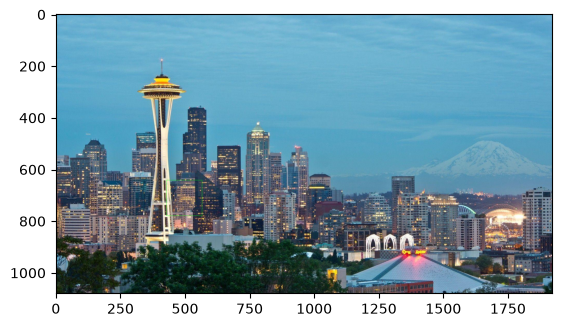

In [11]:
# face detection on the input image
face = detect_face(img_copy1)
plt.imshow(face)

# Saving the Image
cv2.imwrite('face.jpg', face)

In [3]:
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')

In [ ]:
# create a function to detect eyes
def detect_eyes(img, scaleFactor, minNeighbors):
    eye_img = img.copy()
    height, width, channels = eye_img.shape

    eye_rect = eye_cascade.detectMultiScale(eye_img, scaleFactor=scaleFactor, minNeighbors=minNeighbors,
                                            minSize=(int(width * 0.15), int(height * 0.15)))

    for (x,y,w,h) in eye_rect:
        # red box for eyes
        cv2.rectangle(eye_img, (x,y), (x+w, y+h), (255,0,0), 1)

    return eye_img

In [8]:
# loading all training images
img_arr = [i for i in range(0,5)]
#r = [i for i in range(0,5)][j for j in range(101,201,1)][k for k in range(1,10,1)]
#r = np.zeros((5,100,10))
r = [[[0 for i in range(10)] for j in range(100)] for k in range(5)]


for i in range(1, 6):
    img_arr[i-1] = img.copy()

for i in range(0,5):
    for scaleFactor in range(101, 201, 1):
        for minNeighbors in range(1, 10, 1):
            #element = r[i,scaleFactor-101,minNeighbors-1]
            #r[i,scaleFactor-101,minNeighbors-1] = detect_eyes(img_arr[i], scaleFactor/100, minNeighbors)
            r[i][scaleFactor-101][minNeighbors-1] = detect_eyes(img_arr[i], scaleFactor/100, minNeighbors)
            #plt.imshow(eyes)
            #cv2.imwrite('face_eyes.jpg', eyes)

#print(r)

In [ ]:

df = pd.DataFrame(index=[k for k in range(1,11,1)],columns=[j/100 for j in range(101,201,1)])
avg = [[0 for j in range(100)] for i in range(10)]



for minNeighbors in range(1, 11, 1):
    for scaleFactor in range(101, 201, 1):
        for i in range(0,5):
            avg[minNeighbors-1][scaleFactor-101] += r[i][scaleFactor-101][minNeighbors-1]

        #print(f"minNeighbors: {minNeighbors-1}, scaleFactor: {scaleFactor-101}, avg: {avg[minNeighbors-1][scaleFactor-101]}")
        df.iat[minNeighbors-1, scaleFactor-101] = avg[minNeighbors-1][scaleFactor-101] / 5

df.to_excel('eye_detection_results.xlsx', index=True, header=True)

[[[176 176 164]
  [181 181 169]
  [184 184 172]
  ...
  [ 72  68  57]
  [ 73  69  58]
  [ 73  69  58]]

 [[174 174 162]
  [180 180 168]
  [183 183 171]
  ...
  [ 70  66  55]
  [ 71  67  56]
  [ 71  67  56]]

 [[172 172 160]
  [178 178 166]
  [182 182 170]
  ...
  [ 69  65  54]
  [ 70  66  55]
  [ 71  67  56]]

 ...

 [[227 247 245]
  [225 245 243]
  [224 243 241]
  ...
  [ 26  27  32]
  [ 27  28  33]
  [ 27  28  33]]

 [[226 246 244]
  [226 246 244]
  [224 243 241]
  ...
  [ 27  28  33]
  [ 27  28  33]
  [ 27  28  33]]

 [[225 245 243]
  [226 246 244]
  [224 243 241]
  ...
  [ 27  28  33]
  [ 27  28  33]
  [ 27  28  33]]]


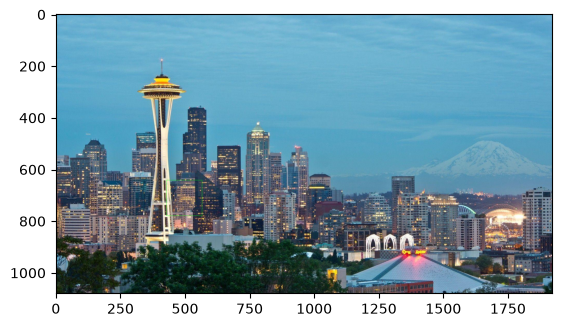

In [15]:
# combine face and eye detection
eyes_face = detect_face(img_copy3)
eyes_face = detect_eyes(eyes_face)
plt.imshow(eyes_face)